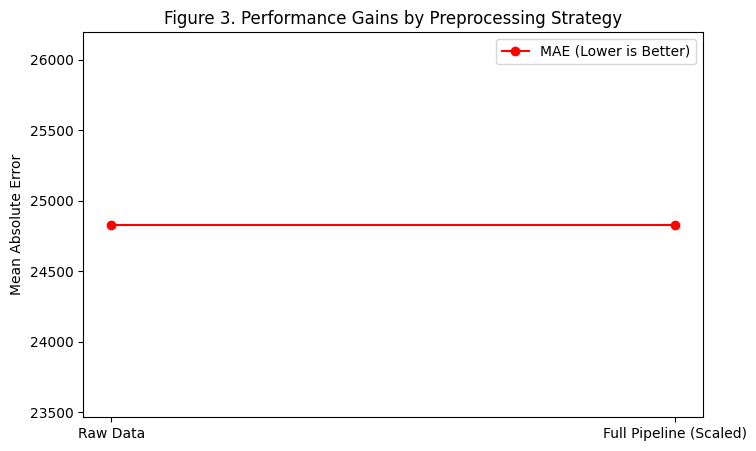

RQ3 Complete! Check Output folder for Table III and Figure 3.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

# 2. Methodology: Pipeline Comparison
def evaluate_pipeline(data, apply_scaling=False):
    # Cleaning
    cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
    df_clean = data.drop(columns=cols_to_drop)
    df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)
    
    X = df_clean.drop(columns=['Revenue_Generated'])
    y = df_clean['Revenue_Generated']
    
    if apply_scaling:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
    preds = model.predict(X_test)
    
    return {
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

# 3. Get Results
raw_results = evaluate_pipeline(df, apply_scaling=False)
scaled_results = evaluate_pipeline(df, apply_scaling=True)

# 4. Save Table III
results_df = pd.DataFrame([
    {"Strategy": "Raw Data", "MAE": raw_results["MAE"], "R2": raw_results["R2"]},
    {"Strategy": "Full Pipeline (Scaled)", "MAE": scaled_results["MAE"], "R2": scaled_results["R2"]}
])
results_df.to_csv('RQ3_Preprocessing_Impact.csv', index=False)

# 5. Save Figure 3 (Comparison Plot)
plt.figure(figsize=(8, 5))
plt.plot(results_df["Strategy"], results_df["MAE"], marker='o', linestyle='-', color='red', label='MAE (Lower is Better)')
plt.title('Figure 3. Performance Gains by Preprocessing Strategy')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.savefig('RQ3_Preprocessing_Plot.pdf')
plt.show()

print("RQ3 Complete! Check Output folder for Table III and Figure 3.")